In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)

# Load dataset
file_name = "category.csv"
df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (297, 13)


,S.No,Country,City,Company,LINKEDIN LINK,Website,Tech Need / Problem,EMAIL,CONTACT,Google Map,Category,Ratings,Reviews
0,1,India,Lucknow,Ladies First Beauty Salon,NaN,NaN,NaN,NaN,7499858640,https://maps.app.goo.gl/zQKMiLRnw9RziQSh6,Beauty Salon,4.5,399
1,2,India,Lucknow,Priya Beauty Salon,NaN,NaN,NaN,NaN,8881200100,https://maps.app.goo.gl/jm5JRZPhwYTUJqSR9,Beauty Salon,4.8,55
2,3,India,Lucknow,Looks,NaN,NaN,NaN,NaN,9919990738,https://maps.app.goo.gl/3B8ZhGzqW2v8Pb5R7,Beauty Salon,4.8,329
3,4,India,Lucknow,Glow N Glam\r,NaN,NaN,NaN,NaN,9919736852,https://maps.app.goo.gl/aQTVy4qYCbXqdmMK6,Beauty Salon,4.6,221
4,5,USA,New York,NY-2 Food Market,NaN,NaN,NaN,NaN,12125822075,https://maps.app.goo.gl/QNWKnhprAJ5gZAmUA,Grocery Store,4.3,55


In [2]:
# Basic information
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))


Column Names:
['S.No', 'Country', 'City', 'Company', 'LINKEDIN LINK', 'Website', 'Tech Need / Problem', 'EMAIL', 'CONTACT', 'Google Map', 'Category', 'Ratings', 'Reviews']

Missing Values:


,Missing Values
S.No,0
Country,0
City,0
Company,0
LINKEDIN LINK,297
Website,297
Tech Need / Problem,297
EMAIL,297
CONTACT,0
Google Map,0



Data Types:


,Data Type
S.No,int64
Country,object
City,object
Company,object
LINKEDIN LINK,float64
Website,float64
Tech Need / Problem,float64
EMAIL,float64
CONTACT,int64
Google Map,object


In [3]:
# Clean text categories
df["Clean_Category"] = (
    df["Category"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Map category variants to the canonical category names used by the priority rules
category_map = {
    "beauty parlour": "Beauty Salon",
    "beauty salon": "Beauty Salon",
    "cake shop": "Cake Shop",
    "cake shop and bakery": "Cake Shop",
    "bakery": "Cake Shop",
    "wine store": "Wine Store",
    "home goods store": "Home Goods Store",
    "grocery store": "Grocery Store",
    "general store": "General Store",
    "building materials store": "Building Materials Store",
    "clothing store": "Clothing Store",
    "pharmacy": "Pharmacy",
    "garage": "Garage",
    "restaurant": "Restaurant",
    "tailor": "Tailor"
}

df["Clean_Category"] = df["Clean_Category"].map(category_map).fillna(
    df["Clean_Category"].str.title()
)

print("Cleaned Categories:")
display(df["Clean_Category"].value_counts().to_frame("Count"))

Cleaned Categories:


,Count
Clean_Category,
Pharmacy,93
General Store,42
Cake Shop,41
Restaurant,23
Tailor,20
Beauty Salon,20
Garage,19
Wine Store,18
Grocery Store,16


In [4]:
def assign_lead_score(category_name):
    high_prob_cats = [
        "Restaurant",
        "Beauty Salon",
        "Building Materials Store"
    ]

    med_prob_cats = [
        "Home Goods Store",
        "Cake Shop",
        "Tailor",
        "General Store",
        "Wine Store",
        "Grocery Store"
    ]

    low_prob_cats = [
        "Pharmacy",
        "Garage",
        "Clothing Store"
    ]

    if category_name in high_prob_cats:
        return 0.85
    elif category_name in med_prob_cats:
        return 0.55
    elif category_name in low_prob_cats:
        return 0.15
    else:
        return 0.15

df["Conversion_Probability"] = df["Clean_Category"].apply(assign_lead_score)

print("Conversion Probability Distribution:")
display(df["Conversion_Probability"].value_counts().sort_index().to_frame("Count"))

Conversion Probability Distribution:


,Count
Conversion_Probability,
0.15,114
0.55,139
0.85,44


In [5]:
print("Total Records:", len(df))
print("\nCity Counts:")
display(df["City"].value_counts().to_frame("Count"))

print("Top Categories:")
display(df["Clean_Category"].value_counts().head(15).to_frame("Count"))

Total Records: 297

City Counts:


,Count
City,
Lucknow,159
New York,90
Patna,48


Top Categories:


,Count
Clean_Category,
Pharmacy,93
General Store,42
Cake Shop,41
Restaurant,23
Tailor,20
Beauty Salon,20
Garage,19
Wine Store,18
Grocery Store,16


### Graph 1
Category distribution

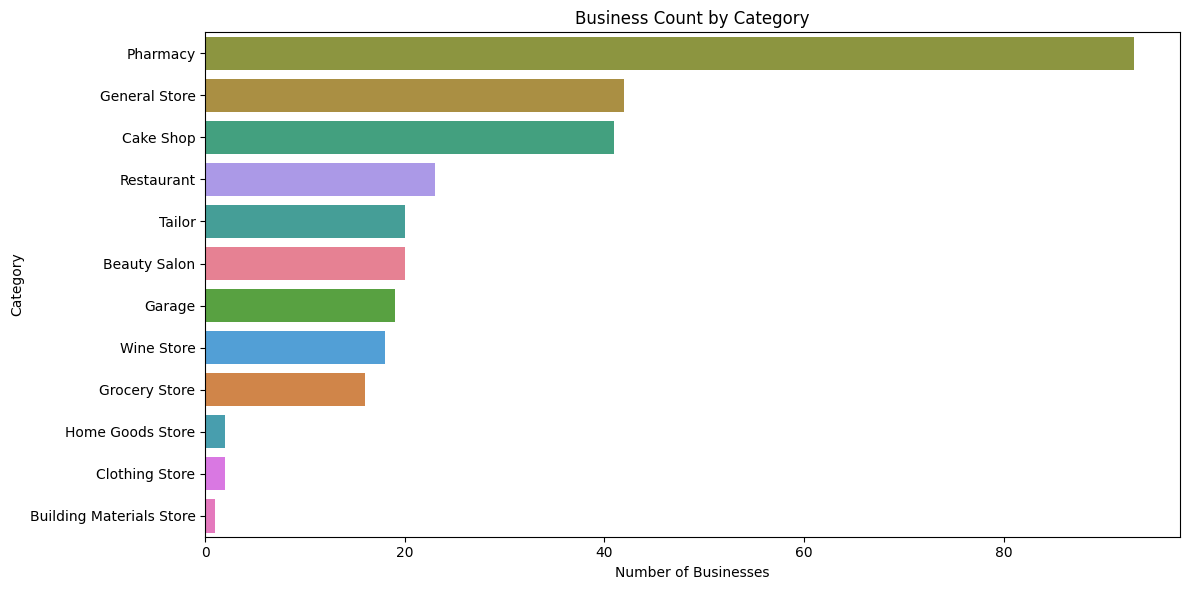

In [6]:
# Category distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y="Clean_Category", order=df["Clean_Category"].value_counts().index, hue="Clean_Category", legend=False)
plt.title("Business Count by Category")
plt.xlabel("Number of Businesses")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("top_business_categories_by_count.png")
plt.show()

### Graph 2
City distribution

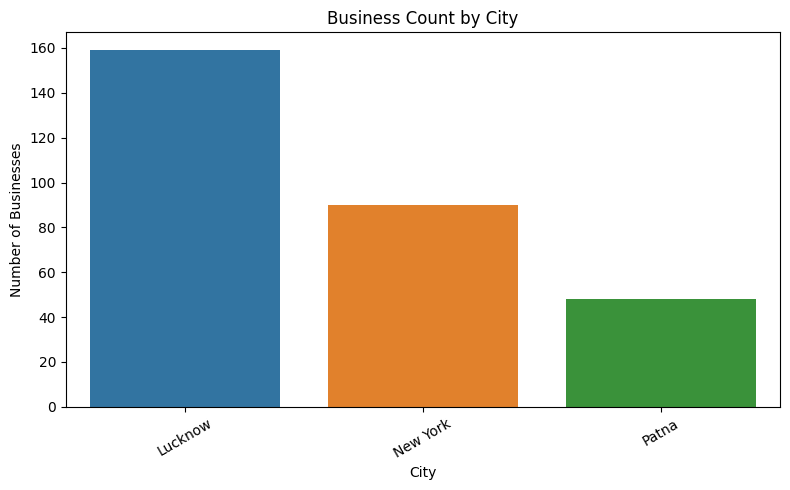

In [7]:
# City distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="City", order=df["City"].value_counts().index, hue="City", legend=False)
plt.title("Business Count by City")
plt.xlabel("City")
plt.ylabel("Number of Businesses")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("distribution_of_businesses_by_city.png")
plt.show()

In [8]:
# Row-level features (safe to calculate before splitting)
df["Company_Name_Length"] = df["Company"].astype(str).str.len()
df["Company_Word_Count"] = df["Company"].astype(str).str.split().str.len()

# Keep raw columns needed for leakage-safe encoding
model_raw_cols = ["Clean_Category", "City", "Company_Name_Length", "Company_Word_Count"]
model_df = df[model_raw_cols].copy()

# Split first -- important for leakage prevention
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    model_df,
    df["Conversion_Probability"],
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train_raw))
print("Testing rows:", len(X_test_raw))

Training rows: 237
Testing rows: 60


In [9]:
# Learn frequency maps from training data ONLY
category_freq_map = X_train_raw["Clean_Category"].value_counts()
city_freq_map = X_train_raw["City"].value_counts()

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

X_train["Category_Frequency"] = X_train["Clean_Category"].map(category_freq_map).fillna(0)
X_test["Category_Frequency"] = X_test["Clean_Category"].map(category_freq_map).fillna(0)

X_train["City_Frequency"] = X_train["City"].map(city_freq_map).fillna(0)
X_test["City_Frequency"] = X_test["City"].map(city_freq_map).fillna(0)

# Learn category/city encodings from training data ONLY
category_encoding = {cat: i for i, cat in enumerate(sorted(X_train["Clean_Category"].unique()))}
city_encoding = {city: i for i, city in enumerate(sorted(X_train["City"].unique()))}

X_train["Category_Encoded"] = X_train["Clean_Category"].map(category_encoding).fillna(-1)
X_test["Category_Encoded"] = X_test["Clean_Category"].map(category_encoding).fillna(-1)

X_train["City_Encoded"] = X_train["City"].map(city_encoding).fillna(-1)
X_test["City_Encoded"] = X_test["City"].map(city_encoding).fillna(-1)

feature_names = [
    "Company_Name_Length",
    "Company_Word_Count",
    "Category_Frequency",
    "City_Frequency",
    "City_Encoded",
    "Category_Encoded"
]

X_train_model = X_train[feature_names].copy()
X_test_model = X_test[feature_names].copy()

print("Model Features:")
display(X_train_model.head())

Model Features:


,Company_Name_Length,Company_Word_Count,Category_Frequency,City_Frequency,City_Encoded,Category_Encoded
273,21,3,18,72,1,10
259,18,2,73,37,2,8
30,18,3,73,128,0,8
22,23,3,73,128,0,8
277,20,3,73,37,2,8


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_model, y_train)

# IMPORTANT: evaluate only on unseen test data
test_predictions = rf_model.predict(X_test_model)

train_r2 = rf_model.score(X_train_model, y_train)
test_r2 = r2_score(y_test, test_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
print(f"Testing MAE: {test_mae:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")

Training R²: 0.9975
Testing R²: 0.9999
Testing MAE: 0.0004
Testing RMSE: 0.0020


In [11]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)



,Feature,Importance
2,Category_Frequency,8.364671e-01
5,Category_Encoded,1.625914e-01
0,Company_Name_Length,7.969645e-04
1,Company_Word_Count,1.445446e-04
3,City_Frequency,1.598429e-16
4,City_Encoded,1.959961e-17


In [12]:
# Build full-dataset features using ONLY maps learned from training data
final_X = model_df.copy()

final_X["Category_Frequency"] = final_X["Clean_Category"].map(category_freq_map).fillna(0)
final_X["City_Frequency"] = final_X["City"].map(city_freq_map).fillna(0)
final_X["Category_Encoded"] = final_X["Clean_Category"].map(category_encoding).fillna(-1)
final_X["City_Encoded"] = final_X["City"].map(city_encoding).fillna(-1)

final_X_model = final_X[feature_names].copy()

# Final scores for all businesses
df["Predicted_Probability"] = rf_model.predict(final_X_model)

# Priority tiers
def assign_priority(score):
    if score >= 0.75:
        return "High Probability (Priority 1)"
    elif score >= 0.45:
        return "Medium Probability (Priority 2)"
    else:
        return "Low Probability (Priority 3)"

df["Priority"] = df["Predicted_Probability"].apply(assign_priority)

print("Final Priority Counts:")
display(df["Priority"].value_counts().to_frame("Count"))

Final Priority Counts:


,Count
Priority,
Medium Probability (Priority 2),140
Low Probability (Priority 3),114
High Probability (Priority 1),43


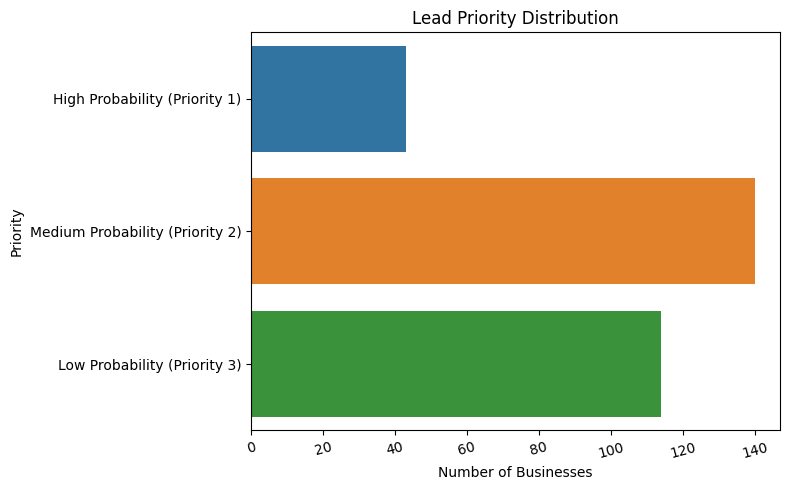

In [13]:
# Priority distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    y="Priority",
    order=[
        "High Probability (Priority 1)",
        "Medium Probability (Priority 2)",
        "Low Probability (Priority 3)"
    ],
    hue="Priority",
    legend=False
)
plt.title("Lead Priority Distribution")
plt.ylabel("Priority")
plt.xlabel("Number of Businesses")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("lead_priority_distribution")
plt.show()

In [14]:
# Top high-priority businesses
high_priority = (
    df[df["Priority"] == "High Probability (Priority 1)"]
    .sort_values("Predicted_Probability", ascending=False)
)

print("Top High Priority Businesses:")
display(high_priority[["Company", "City", "Clean_Category", "Predicted_Probability", "Priority"]].head(20))

Top High Priority Businesses:


,Company,City,Clean_Category,Predicted_Probability,Priority
0,Ladies First Beauty Salon,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)
1,Priya Beauty Salon,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)
2,Looks,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)
3,Glow N Glam\r,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)
131,Shopping Girlfriend NYC,New York,Beauty Salon,0.85,High Probability (Priority 1)
133,VR UNISEX SALON,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)
134,The London,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)
135,Xatisfy Men Salon,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)
136,The Invite Unisex Salon,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)
137,Super Style Salon,Lucknow,Beauty Salon,0.85,High Probability (Priority 1)


In [15]:
# Average predicted probability by category
category_ranking = (
    df.groupby("Clean_Category")["Predicted_Probability"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
category_ranking.columns = ["Category", "Average_Predicted_Probability"]

print("Category Ranking:")
display(category_ranking)

Category Ranking:


,Category,Average_Predicted_Probability
0,Beauty Salon,0.850000
1,Restaurant,0.850000
2,Building Materials Store,0.669000
3,Grocery Store,0.552062
4,Wine Store,0.550000
5,Cake Shop,0.550000
6,Home Goods Store,0.550000
7,General Store,0.550000
8,Tailor,0.550000
9,Clothing Store,0.191500


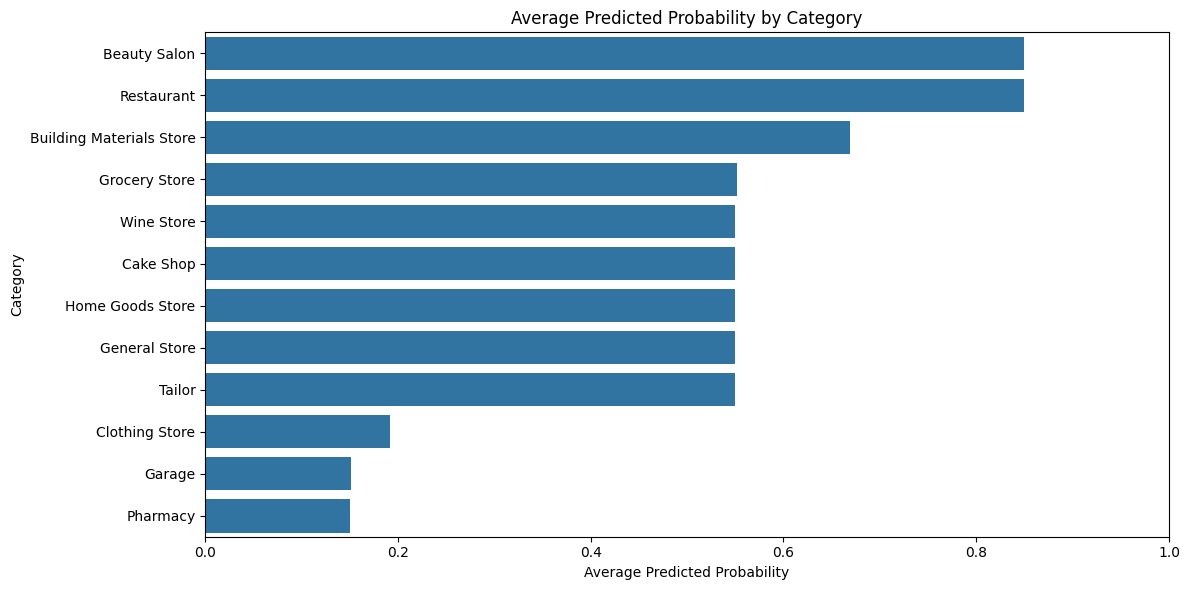

In [16]:
# Graph: Average predicted probability by category

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_ranking,
    x="Average_Predicted_Probability",
    y="Category"
)

plt.title("Average Predicted Probability by Category")
plt.xlabel("Average Predicted Probability")
plt.ylabel("Category")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("average_predicted_probability_by_category")
plt.show()

In [17]:
# Save CSV
df.to_csv("Business_Lead_Scoring_Output_Updated.csv", index=False)

# Create Excel output with priority sheets
output_file = "Business_Lead_Scoring_Output_Updated.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="All Businesses", index=False)
    high_priority.to_excel(writer, sheet_name="High Priority", index=False)
    df[df["Priority"] == "Medium Probability (Priority 2)"].sort_values(
        "Predicted_Probability", ascending=False
    ).to_excel(writer, sheet_name="Medium Priority", index=False)
    df[df["Priority"] == "Low Probability (Priority 3)"].sort_values(
        "Predicted_Probability", ascending=False
    ).to_excel(writer, sheet_name="Low Priority", index=False)
    category_ranking.to_excel(writer, sheet_name="Category Ranking", index=False)
    feature_importance.to_excel(writer, sheet_name="Feature Importance", index=False)

print("Saved:")
print("Business_Lead_Scoring_Output_Updated.csv")
print("Business_Lead_Scoring_Output_Updated.xlsx")

Saved:
Business_Lead_Scoring_Output_Updated.csv
Business_Lead_Scoring_Output_Updated.xlsx


### Important Note on Leakage & Evaluation
- Category_Frequency and City_Frequency are calculated from the training set only.
- Category_Encoded and City_Encoded are also learned from the training set only; unseen test values become -1.
- Model performance is reported using X_test only.
- rf_model.predict(final_X_model) is used only to create final business scores for all rows. Those full-dataset predictions should not be used to claim test performance.
- Because the target probability is manually assigned from category rules, the model is learning to reproduce the predefined scoring system rather than learning actual observed conversion behavior.